# Introduction to Neural Network Classification

In my previous article, I have shown you how easily we can make a regression model using TensorFlow.

In this article, I'm going to discuss classification models using TensorFlow.

- [LinkedIn](https://www.linkedin.com/in/pro-programmer/),
- [YouTube](http://www.youtube.com/@itvaya),
- [Gmail](talukderrishat2@gmail.com),
- [discord](https://discord.gg/ZB495XggcF),

**You can find all my articles and code on **

- [Deep Learning With Tensorflow](https://github.com/RishatTalukder/Deep_Learning_With_Tensorflow),

**If you are new to Machine learning, I also have a github for begennier machine learning.**

- [Machine Learning Zero to Hero](https://github.com/RishatTalukder/Machine-Learning-Zero-to-Hero)

**Pre-requisites**

- Python.
- Numpy.
- Pandas.
- Matplotlib/Seaborn.
- Basics of data analysis and preprocessing.
- Basics ML terminologies.
- Basics Tensorflow and keras terminologies.
- Basics of Neural Network.

**Installations**

So, as we are making a `neural network using TensorFlow`, we will need to install it. To do so, we will use the following command:

```bash
    pip install tensorflow
```

or If you have conda installed,
    
```bash
    conda install tensorflow
```

Now, let's import the necessary libraries and check the version of TensorFlow we are using.

# Introduction

First let's answer the question "What is Classification?"

`Classification` Is  the process of grouping data points into `categories` or `classes` based on some criteria.

Simply put, when A model predicts a `category` instead of a `value`, it is called a `classification model`.

For example, a model that predicts whether a customer will buy a product or not is a classification model.

Or, let's say you have a dataset of images of cats and dogs. The model will  onyl predict whether the image is a cat or a dog.

Here's the model is not predicting a value but a `group`.


There can be two types of classification models:

- Binary classification.
- Multi-class classification.

**Binary classification**

In binary classification, the model predicts `two` categories. For example,

Let's say we have a dataset like this:

|   |   |  Target |
| --- | --- | --- |
| 1 | 1 | 1 |
| 2 | 1 | 0 |
| 3 | 0 | 1 |
| 4 | 0 | 0 |
| 5 | 1 | 0 |
| 6 | 0 | 1 |
| 7 | 1 | 1 |
| 8 | 0 | 0 |
| 9 | 1 | 1 |

As you can see the target feature only have two categories `0` and `1`. And the model will predict `0` or `1` based on the features.

**Multi-class classification**

In multi-class classification, the model predicts; Drum Roll please 🥁; You guessed it, `more than two` classes... WHAAAT!!! Is that even possible.

I should stop. That was very very cheesy.

That's it. Nice a easy right?? But I think you know all this. You are here to knwo something more than just What the definitions of classification. You wnat to know how to actually make and train the model.

So For this Let's make some data.

In [4]:
from sklearn.datasets import make_moons
from matplotlib import pyplot as plt

X, y = make_moons(1000, noise=0.05)

`Sklearn` has some nice functions to make dummy data for us. `make_moons` will create a dataset for two interleaving half circles. 

We just have to pass arguments for the number of samples and the noise level and it'll return the `X` set and the `y` set.

I have them stored in the `X` and `y` variables.

Let's try to visualize the data first and see what the pattern looks like.

In [5]:
import pandas as pd

data = pd.DataFrame(
    data={
        'X1': X[:, 0],
        'X2': X[:, 1],
        'y': y
    }
)

data.head()

,X1,X2,y
0,0.579327,-0.368987,1
1,-0.078852,0.948563,0
2,0.008823,0.605552,1
3,0.884656,-0.540023,1
4,-0.596280,0.851921,0


I've turned the data into a pandas dataframe for ease of use. As you can see the `y` column only has two categories `0` and `1`.

Now, we can just plot the `X1` vs `X2` graph and see what the pattern looks like.

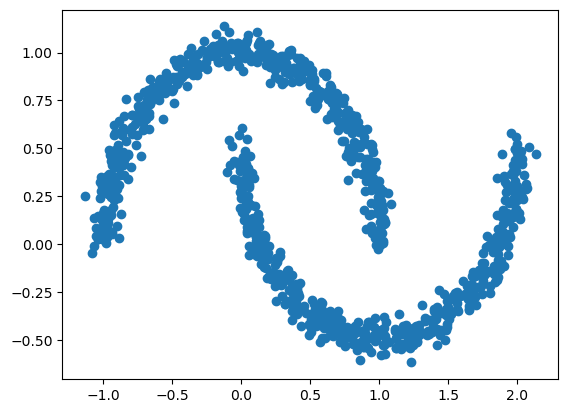

In [6]:
plt.scatter(
    x=data['X1'],
    y=data['X2'],
)

HMMMMMMM! very nice!

But what are the categories here.

We can just colormap the points based on the `y` values to see the pattern.

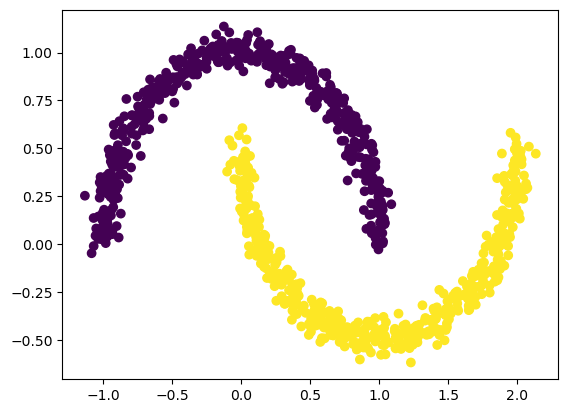

In [7]:
plt.scatter(
    x=data['X1'],
    y=data['X2'],
    c=data['y'],
    cmap='viridis'
)

And we have two nice little half circles with a bit of noise. And the pattern looks nice. Now, What I want you to do is make a dataset with the `make_circles` function and plot it so that you can do your own experiments.

And before going deeper, I want you to go to [this](https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.51124&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false) website and play around a bit.

Now, Let's see the shapes of our data.

In [8]:
X.shape, y.shape

((1000, 2), (1000,))

In the, feature set we have `1000` rows and `2` columns and the target set we have `1000` rows.

This will come in handy when we build the model.

Now, that we have our data, the next step is to split it into train and test sets.

## Splitting the data

We can use the `train_test_split` function from `sklearn` to split the data into train and test sets.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

And done, we have split the data into train and test sets. The test set will be 20% of the data and the train set will be 80% of the data.

Now, let's make a model.

# Building the model

We can just make a normal neural network model like a regression model. But the problem will arrive very soon.

First let's check the target column.

In [10]:
import numpy as np

print(f"Minimum target value: {y.min()}")
print(f"Maximum target value: {y.max()}")

print(f"Unique target values: {np.unique(y)}")

Minimum target value: 0
Maximum target value: 1
Unique target values: [0 1]


As you can see, the target column has two unique values `0` and `1`. This is called a `binary classification` problem. 

> If the target feature contains only two unique values then it is called a `binary classification` problem.

So, the question for you is, (I'm assuming you already know how to make a regression model) If we take a single neuron in the last layer will it be able to predict `0` and `1` only?

Theoretically, yes. But practically, no.

Let me explain it with an example.

Imagine we train our model to predict whether an email is spam (1) or not spam (0). A single raw neuron calculates a weighted sum of its inputs plus a bias ($z = w \cdot x + b$).

Because this calculation is purely linear, the output can be any continuous number—like 0.85, -2.3, or 105.6. It does not naturally stop at exactly 0 or 1. If a user gets a prediction of 0.74, the computer cannot definitively say "yes" or "no" without extra instructions.

Now, how do we fix this?

We pass the output neuron through an activation function. More specifically a function that will output a number between 0 and 1. So, we use the `sigmoid` activation function. 

The sigmoid function takes any real-valued number and maps it to a value between 0 and 1. 

So, if the output of the neuron is 0.74, the sigmoid function will convert it to a value between 0 and 1, which can be interpreted as a probability. If the output is greater than 0.5, we can classify it as spam (1), and if it's less than or equal to 0.5, we classify it as not spam (0).

So, let's build a model.

In [ ]:
from keras import activations, layers, models

model = models.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(5, activation=activations.leaky_relu),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 5)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21 (84.00 B)

 Trainable params: 21 (84.00 B)

 Non-trainable params: 0 (0.00 B)

Alright we have a very small model. Only 21 parameters.

And there's something new here too.

The model looks like this:

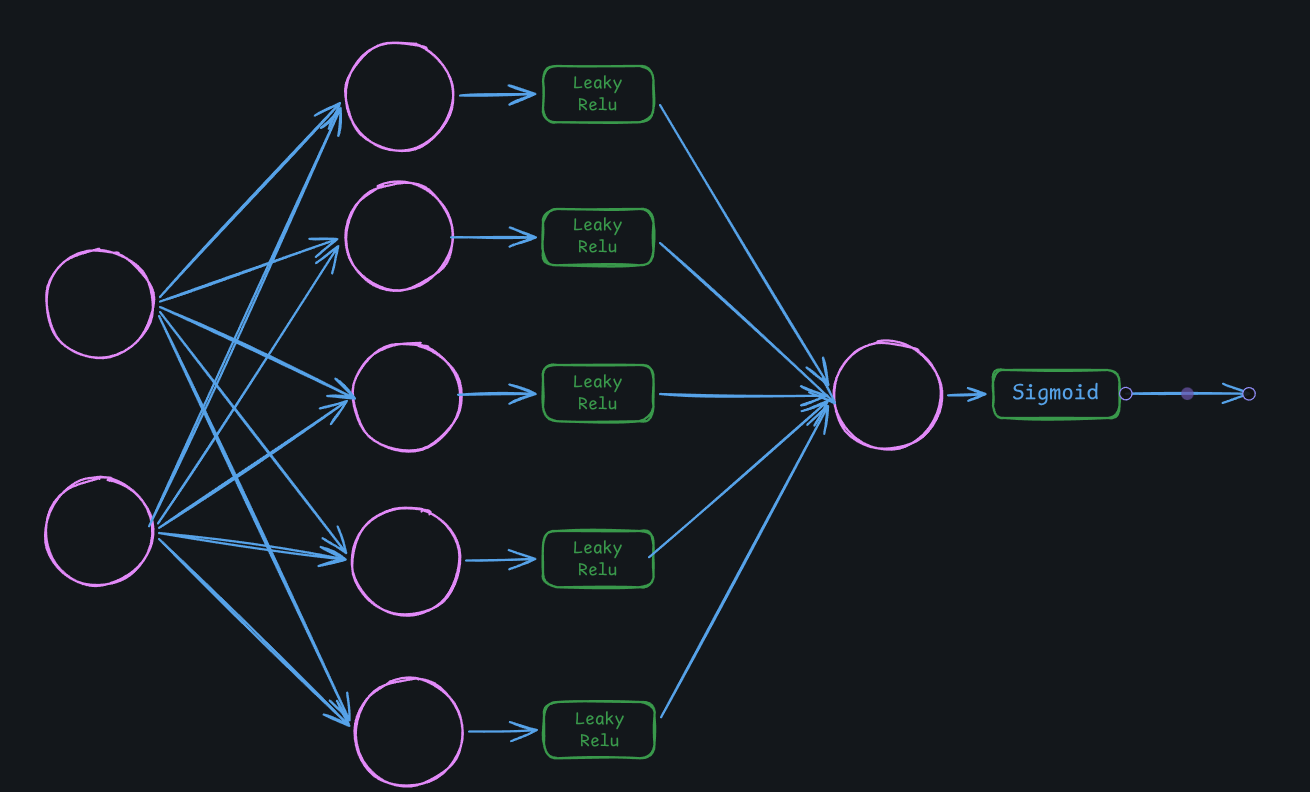

In the hidden layer, I have 5 perceptrons and each have a activation of `leaky_relu`.

**Why I Chose Leaky ReLU Over Standard ReLU?**

To answere this question, first we have to take a look at the range of our feature set.

In [13]:
data[['X1', 'X2']].describe()

,X1,X2
count,1000.000000,1000.000000
mean,0.502729,0.252470
std,0.868070,0.495847
min,-1.131666,-0.618257
25%,-0.024999,-0.205830
50%,0.505905,0.260903
75%,1.031720,0.701076
max,2.133651,1.136238


AS you can see both features have a range from `negetive` to `positive` numbers.

So, What does `ReLu` do?

It takes a number and returns 0 if the number is negetive and the number if it is positive.

So, it literally **removes** the negetive numbers. So, What happends if the activation value from a neuron is negetive? It becomes 0.

When this 0 passes to the next layer, it multiplies by the next layer's weights and stays 0. This means this specific neuron contributes absolutely nothing to the next layer, making its connection completely useless. If too many neurons do this, large parts of your network go dark and stop learning entirely."

> This trap is famously known as the "Dying ReLU" problem.

To prevent our neurons from permanently flatlining, we can swap standard ReLU for `Leaky ReLU`.

Instead of aggressively dropping negative values off a cliff to a hard 0, Leaky ReLU leaves the door slightly ajar. If a value is positive, it leaves it alone. But if a value is negative, it multiplies it by a tiny fraction, usually 0.01. (In tensorflow it is 0.2)

Mathematically, the leaky ReLU activation function is defined as:

$$f(x) = \max(Negetive Slope * x, x)$$

By allowing a tiny "leak" of negative information to flow through, the activation value never becomes a absolute, dead-end zero. When this small value passes to the next layer, its gradient remains alive